In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
store_cleaned = pd.read_csv(r'E:\data-science-projects\Rossmann Store Sales\data\processed\store_cleaned.csv')
train_cleaned = pd.read_csv(r'E:\data-science-projects\Rossmann Store Sales\data\processed\train_cleaned.csv')
test_cleaned = pd.read_csv(r'E:\data-science-projects\Rossmann Store Sales\data\processed\test_cleaned.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_18356\434394389.py:2: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_cleaned = pd.read_csv(r'E:\data-science-projects\Rossmann Store Sales\data\processed\train_cleaned.csv')


In [7]:
store_cleaned.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
store_cleaned.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [9]:
store_cleaned.isnull().sum()   

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [10]:
store_cleaned['CompetitionDistance'].fillna(store_cleaned['CompetitionDistance'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18356\1421491701.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  store_cleaned['CompetitionDistance'].fillna(store_cleaned['CompetitionDistance'].median(), inplace=True)


0        1270.0
1         570.0
2       14130.0
3         620.0
4       29910.0
         ...   
1110     1900.0
1111     1880.0
1112     9260.0
1113      870.0
1114     5350.0
Name: CompetitionDistance, Length: 1115, dtype: float64

In [11]:
cols = ['CompetitionOpenSinceMonth','CompetitionOpenSinceYear','Promo2SinceWeek','Promo2SinceYear']
store_cleaned[cols].fillna(0, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18356\350806229.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  store_cleaned[cols].fillna(0, inplace=True)


,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear
0,9.0,2008.0,0.0,0.0
1,11.0,2007.0,13.0,2010.0
2,12.0,2006.0,14.0,2011.0
3,9.0,2009.0,0.0,0.0
4,4.0,2015.0,0.0,0.0
...,...,...,...,...
1110,6.0,2014.0,31.0,2013.0
1111,4.0,2006.0,0.0,0.0
1112,0.0,0.0,0.0,0.0
1113,0.0,0.0,0.0,0.0


In [12]:
store_cleaned['PromoInterval'].fillna('None', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18356\672978277.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  store_cleaned['PromoInterval'].fillna('None', inplace=True)


0                   None
1        Jan,Apr,Jul,Oct
2        Jan,Apr,Jul,Oct
3                   None
4                   None
              ...       
1110     Jan,Apr,Jul,Oct
1111                None
1112                None
1113                None
1114    Mar,Jun,Sept,Dec
Name: PromoInterval, Length: 1115, dtype: str

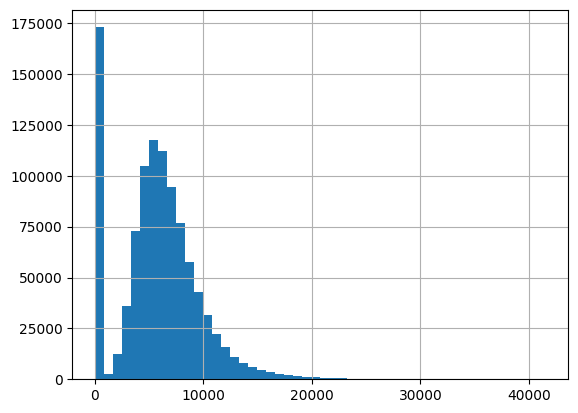

In [13]:
train_cleaned['Sales'].hist(bins=50)
plt.show()

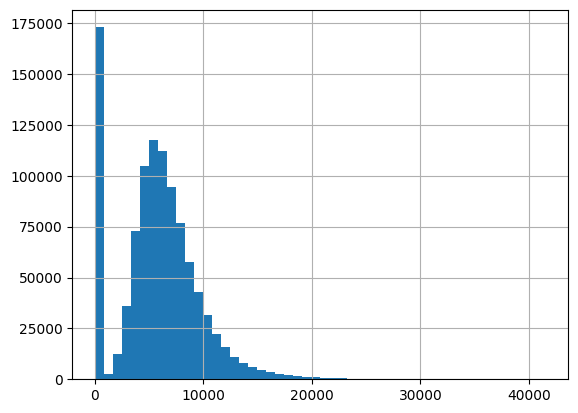

In [14]:
train_cleaned['Sales'].hist(bins=50)
plt.show()

In [19]:
train_cleaned[train_cleaned['Sales'] == 0].shape

(0, 9)

In [17]:
train_cleaned = train_cleaned[train_cleaned['Sales'] > 0]

In [18]:
train_df = train_cleaned.merge(store_cleaned, on='Store', how='left')

In [20]:
train_df['Date'] = pd.to_datetime(train_df['Date'])

train_df['Year'] = train_df['Date'].dt.year
train_df['Month'] = train_df['Date'].dt.month
train_df['Day'] = train_df['Date'].dt.day
train_df['DayOfWeek'] = train_df['Date'].dt.dayofweek

In [21]:
train_df.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31


In [20]:
train_df.groupby('Promo')['Sales'].mean()

Promo
0    5929.826183
1    8228.739731
Name: Sales, dtype: float64

In [22]:
train_df.groupby('StoreType')['Sales'].mean()

StoreType
a     6925.697986
b    10233.380141
c     6933.126425
d     6822.300064
Name: Sales, dtype: float64

In [23]:
train_df.groupby('Assortment')['Sales'].mean()

Assortment
a    6621.523057
b    8642.503594
c    7300.843547
Name: Sales, dtype: float64

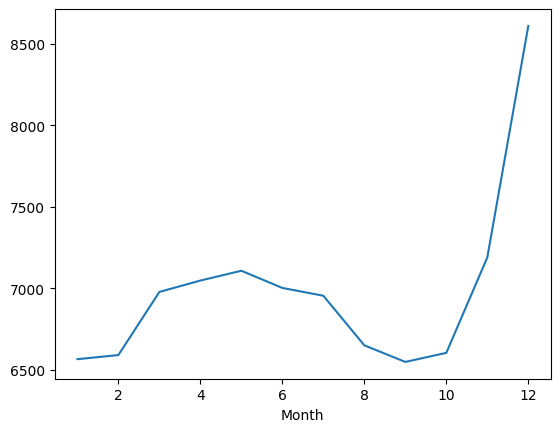

In [24]:
train_df.groupby('Month')['Sales'].mean().plot()
plt.show()

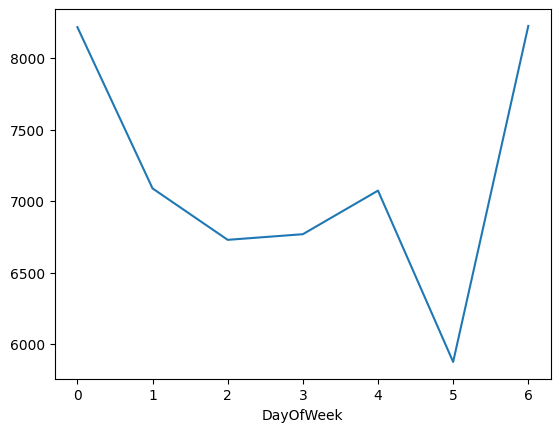

In [25]:
train_df.groupby('DayOfWeek')['Sales'].mean().plot()
plt.show()

In [27]:
train_df.groupby(pd.cut(train_df['CompetitionDistance'], bins=5))['Sales'].mean()

CompetitionDistance
(-55.84, 15188.0]     6961.647012
(15188.0, 30356.0]    7041.604692
(30356.0, 45524.0]    6471.923562
(45524.0, 60692.0]    5980.114445
(60692.0, 75860.0]    7775.446449
Name: Sales, dtype: float64

In [28]:
train_df.corr(numeric_only=True)['Sales'].sort_values(ascending=False)

Sales                        1.000000
Customers                    0.823552
Promo                        0.368199
Promo2SinceWeek              0.095212
Month                        0.073589
SchoolHoliday                0.038635
Year                         0.036151
CompetitionOpenSinceYear     0.016102
Store                        0.007723
Promo2SinceYear             -0.034595
CompetitionDistance         -0.036453
CompetitionOpenSinceMonth   -0.043472
Day                         -0.051865
Promo2                      -0.127556
DayOfWeek                   -0.178753
Open                              NaN
Name: Sales, dtype: float64

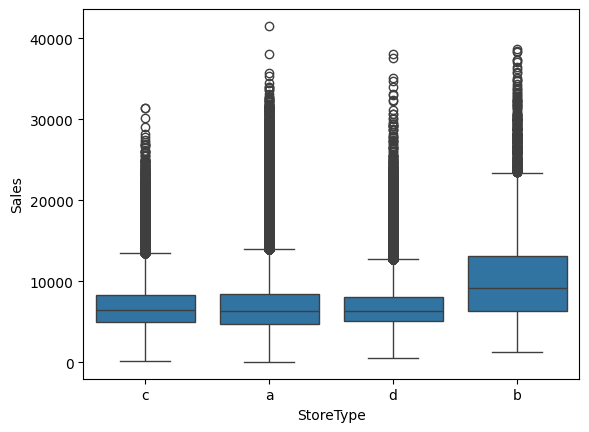

In [22]:
sns.boxplot(x='StoreType', y='Sales', data=train_df)
plt.show()